# Do Receiver Residuals Carry Across Seasons?

A useful route-level model should remove situation from a route's expected separation change. This experiment asks a separate player-level question: after making that adjustment, do the same receivers tend to outperform or underperform the expectation in both 2021 and 2023?

The 2021 values use game-grouped out-of-fold predictions, so no route is scored by a model trained on its game. The 2023 values come from the static and dynamic common-feature ridge models frozen after fitting all eligible 2021 routes. We compare the same shared receiver IDs, center residuals within each season to remove overall year calibration shifts, and require at least 20 routes across at least five games in each season. Player intervals resample games within receiver; correlation intervals resample both receivers and their games.

This is a test of repeatability in these samples, not a causal estimate of receiver talent. The 2023 tracking window is only snap-to-release-like, and the 2021 sample covers Weeks 1–8 while 2023 covers a full season.

In [1]:
from pathlib import Path
import html
import math
import sys
from collections import defaultdict

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from IPython.display import HTML, SVG, display
from separation_over_expected.cross_season import load_cross_season_wr_rows
from separation_over_expected.receiver_reliability import (
    cross_season_receiver_predictions,
    summarize_cross_season_receivers,
)
from separation_over_expected.reports import write_csv

LEGACY_DYNAMIC = PROJECT_ROOT / "data" / "processed" / "dynamic_features" / "route_level_snap_to_release_dynamic.csv"
BDB2023_DYNAMIC = PROJECT_ROOT / "data" / "processed" / "bdb2026" / "route_level_input_window_2023_dynamic.csv"
NFLVERSE_PBP = PROJECT_ROOT.parent / "data" / "big_data_bowl_2026" / "nflverse_play_by_play_2023.csv"
OUTPUT_DIR = PROJECT_ROOT / "data" / "processed" / "cross_season_receiver_reliability"

legacy_wr, bdb2023_wr, join_checks = load_cross_season_wr_rows(
    LEGACY_DYNAMIC, BDB2023_DYNAMIC, NFLVERSE_PBP, require_dynamic=True
)
join_checks

{'legacy_wr_routes': 20413, 'bdb2023_wr_routes': 38002, 'bdb2023_plays_without_context': 0, 'yardline_max_absolute_error': 0.0}

## Score routes without using each route's game for training

Static and dynamic models use the same five folds and the same common static context. The dynamic version adds the 24 summaries of motion from the three nearest coverage defenders. Each 2023 route is scored by a model trained on all of 2021. The route prediction table is kept in the ignored `data/processed` directory so the full analysis can be rerun without committing derived tracking data.

In [2]:
predictions = cross_season_receiver_predictions(
    legacy_wr, bdb2023_wr, n_folds=5, seed=42
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
write_csv(OUTPUT_DIR / "route_predictions.csv", list(predictions[0]), predictions)
len(predictions), sum(row["season"] == "2021" for row in predictions), sum(
    row["season"] == "2023" for row in predictions
)

(58415, 20413, 38002)

In [3]:
route_keys = [(row["season"], row["gameId"], row["playId"], row["nflId"]) for row in predictions]
folds_by_game = defaultdict(set)
for row in predictions:
    if row["season"] == "2021":
        folds_by_game[(row["week"], row["gameId"])].add(row["fold"])
prediction_integrity = {
    "predictions": len(predictions),
    "unique route keys": len(set(route_keys)),
    "2021 games in multiple folds": sum(len(folds) != 1 for folds in folds_by_game.values()),
}
assert prediction_integrity["predictions"] == prediction_integrity["unique route keys"]
assert prediction_integrity["2021 games in multiple folds"] == 0
prediction_integrity

{'predictions': 58415, 'unique route keys': 58415, '2021 games in multiple folds': 0}

## Match receivers and account for sample size

Each player's estimate is their mean route residual minus the season's route-weighted mean residual. Positive values mean that receiver's routes gained more separation than expected relative to the season's average receiver in this sample. Centering removes common season-level model bias; it does not remove team, role, or route-assignment differences.

The route count threshold follows earlier receiver reliability checks. Requiring five distinct games as well prevents a player's estimate from being driven by a small number of high-volume games. Game-cluster bootstrap intervals preserve within-game dependence.

In [4]:
receiver_rows, reliability, receiver_checks = summarize_cross_season_receivers(
    predictions,
    min_routes=20,
    min_games=5,
    bootstrap_samples=2000,
    seed=42,
)
write_csv(OUTPUT_DIR / "receiver_summaries.csv", list(receiver_rows[0]), receiver_rows)
write_csv(OUTPUT_DIR / "reliability_metrics.csv", list(reliability[0]), reliability)
receiver_checks

{'players_2021': 209, 'players_2023': 227, 'shared_player_ids': 128, 'eligible_shared_players': 91, 'min_routes_per_season': 20, 'min_games_per_season': 5, '2021_static_route_bias': -0.0014440980345857897, '2023_static_route_bias': -0.011584789112152006, '2021_dynamic_route_bias': -0.001164169716357247, '2023_dynamic_route_bias': -0.06118295645676575}

In [5]:
reliability

[{'comparison': 'static', 'receivers': '91', 'pearson': '0.375327', 'pearson_ci_lower': '-0.128488', 'pearson_ci_upper': '0.569805', 'spearman': '-0.003679', 'spearman_ci_lower': '-0.166022', 'spearman_ci_upper': '0.281155'}, {'comparison': 'dynamic', 'receivers': '91', 'pearson': '0.458604', 'pearson_ci_lower': '-0.054859', 'pearson_ci_upper': '0.623548', 'spearman': '0.121707', 'spearman_ci_lower': '-0.105845', 'spearman_ci_upper': '0.325602'}, {'comparison': 'dynamic_minus_static', 'receivers': '91', 'pearson': '0.083277', 'pearson_ci_lower': '0.000972', 'pearson_ci_upper': '0.135162', 'spearman': '0.125386', 'spearman_ci_lower': '-0.028957', 'spearman_ci_upper': '0.144842'}]

## Player-by-player performance across seasons

Each point is a receiver with at least 20 routes in five games in both seasons. Horizontal and vertical bars are 95% game-cluster bootstrap intervals for the player's centered residual. The diagonal represents identical average overperformance in both seasons. Hover over a point for the player name, route counts, and estimates.

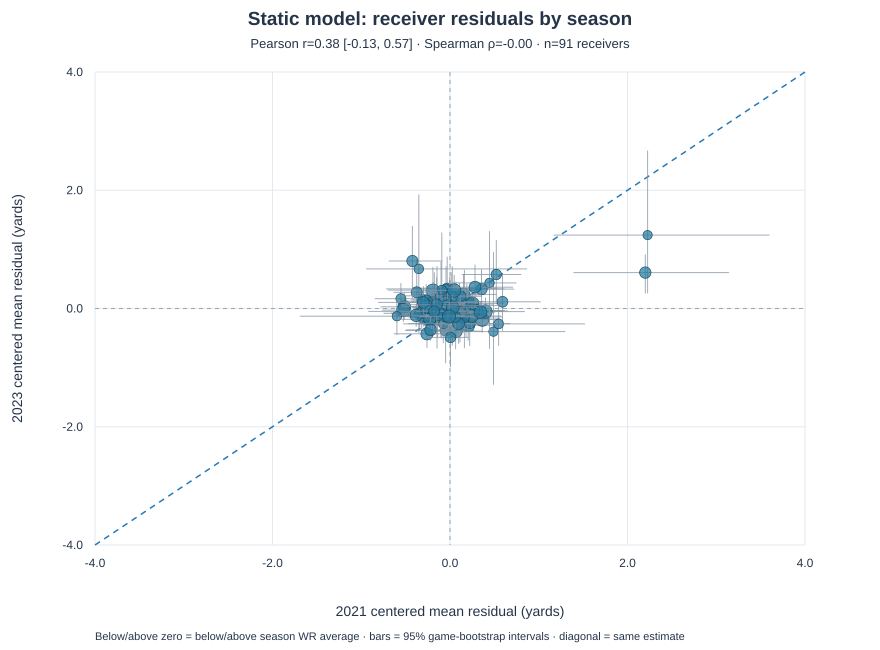

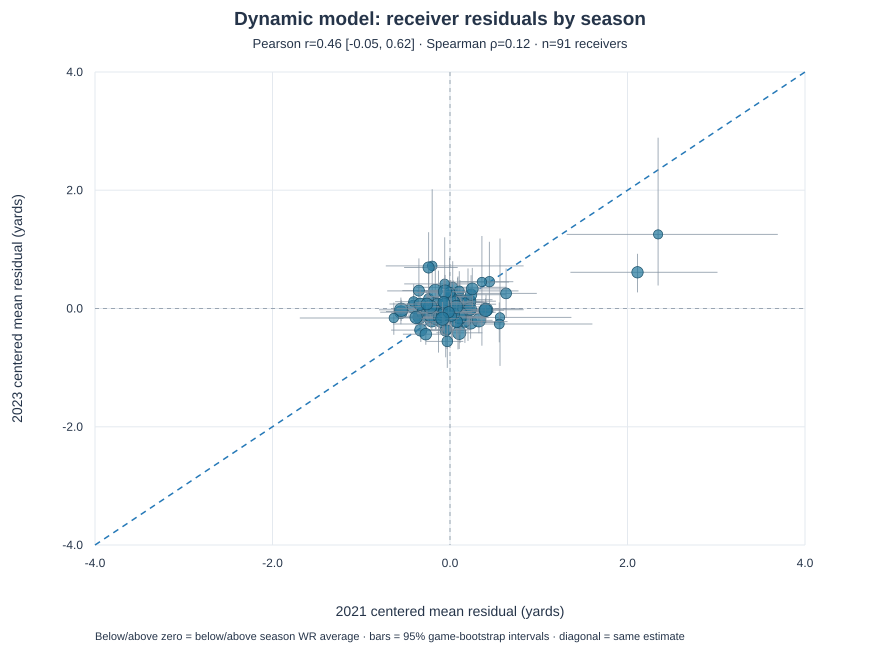

In [6]:
def receiver_scatter_svg(rows, model, metric, width=880, height=650):
    eligible = [row for row in rows if row["eligible"] == "true"]
    x_key, y_key = f"centered_residual_2021_{model}", f"centered_residual_2023_{model}"
    x_lo, x_hi = f"ci_lower_2021_{model}", f"ci_upper_2021_{model}"
    y_lo, y_hi = f"ci_lower_2023_{model}", f"ci_upper_2023_{model}"
    extent = max(
        abs(float(row[key]))
        for row in eligible
        for key in (x_lo, x_hi, y_lo, y_hi)
    )
    limit = max(0.5, math.ceil(extent * 2) / 2)
    left, right, top, bottom = 95, 805, 72, 545
    x_scale = (right - left) / (2 * limit)
    y_scale = (bottom - top) / (2 * limit)
    x_pos = lambda value: left + (float(value) + limit) * x_scale
    y_pos = lambda value: bottom - (float(value) + limit) * y_scale
    metric_title = next(row for row in metric if row["comparison"] == model)
    parts = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">',
        '<rect width="100%" height="100%" fill="#ffffff"/>',
        '<style>text{font-family:Arial,sans-serif;fill:#253449}.grid{stroke:#e4e9ef;stroke-width:1}.zero{stroke:#99a5b2;stroke-dasharray:4 4}.interval{stroke:#8291a0;stroke-width:1;opacity:.75}</style>',
        f'<text x="{width/2}" y="25" text-anchor="middle" font-size="19" font-weight="bold">{model.title()} model: receiver residuals by season</text>',
        f'<text x="{width/2}" y="48" text-anchor="middle" font-size="13">Pearson r={float(metric_title["pearson"]):.2f} [{float(metric_title["pearson_ci_lower"]):.2f}, {float(metric_title["pearson_ci_upper"]):.2f}] · Spearman ρ={float(metric_title["spearman"]):.2f} · n={len(eligible)} receivers</text>',
    ]
    for tick_index in range(5):
        value = -limit + 2 * limit * tick_index / 4
        x, y = x_pos(value), y_pos(value)
        parts.extend([
            f'<line class="grid" x1="{x:.1f}" y1="{top}" x2="{x:.1f}" y2="{bottom}"/>',
            f'<line class="grid" x1="{left}" y1="{y:.1f}" x2="{right}" y2="{y:.1f}"/>',
            f'<text x="{x:.1f}" y="{bottom+22}" text-anchor="middle" font-size="12">{value:.1f}</text>',
            f'<text x="{left-12}" y="{y+4:.1f}" text-anchor="end" font-size="12">{value:.1f}</text>',
        ])
    parts.extend([
        f'<line class="zero" x1="{x_pos(0)}" y1="{top}" x2="{x_pos(0)}" y2="{bottom}"/>',
        f'<line class="zero" x1="{left}" y1="{y_pos(0)}" x2="{right}" y2="{y_pos(0)}"/>',
        f'<line x1="{x_pos(-limit)}" y1="{y_pos(-limit)}" x2="{x_pos(limit)}" y2="{y_pos(limit)}" stroke="#2478b7" stroke-dasharray="6 5" stroke-width="1.5"/>',
    ])
    for row in eligible:
        xv, yv = float(row[x_key]), float(row[y_key])
        x1, x2 = x_pos(row[x_lo]), x_pos(row[x_hi])
        y1, y2 = y_pos(row[y_hi]), y_pos(row[y_lo])
        min_routes = min(int(row[f"routes_2021_{model}"]), int(row[f"routes_2023_{model}"]))
        radius = 3.7 + min(3.0, math.sqrt(min_routes) / 5)
        title = html.escape(
            f'{row["displayName"]} (ID {row["nflId"]}) · 2021: {xv:+.2f} yd, {row[f"routes_2021_{model}"]} routes · 2023: {yv:+.2f} yd, {row[f"routes_2023_{model}"]} routes'
        )
        parts.extend([
            f'<line class="interval" x1="{x1:.1f}" y1="{y_pos(yv):.1f}" x2="{x2:.1f}" y2="{y_pos(yv):.1f}"/>',
            f'<line class="interval" x1="{x_pos(xv):.1f}" y1="{y1:.1f}" x2="{x_pos(xv):.1f}" y2="{y2:.1f}"/>',
            f'<circle cx="{x_pos(xv):.1f}" cy="{y_pos(yv):.1f}" r="{radius:.1f}" fill="#287b9e" fill-opacity=".72" stroke="#164e68" stroke-width=".7"><title>{title}</title></circle>',
        ])
    parts.extend([
        f'<text x="{(left+right)/2}" y="{height-34}" text-anchor="middle" font-size="14">2021 centered mean residual (yards)</text>',
        f'<text x="22" y="{(top+bottom)/2}" text-anchor="middle" font-size="14" transform="rotate(-90 22 {(top+bottom)/2})">2023 centered mean residual (yards)</text>',
        f'<text x="{left}" y="{height-10}" font-size="11" fill="#596878">Below/above zero = below/above season WR average · bars = 95% game-bootstrap intervals · diagonal = same estimate</text>',
        '</svg>',
    ])
    return "".join(parts)


display(SVG(receiver_scatter_svg(receiver_rows, "static", reliability)))
display(SVG(receiver_scatter_svg(receiver_rows, "dynamic", reliability)))

## Does dynamic defender motion improve repeatability?

Pearson correlation measures agreement in receiver residual levels; Spearman correlation measures agreement in ordering. The paired dynamic-minus-static interval uses the same receiver and game resamples for both models. The individual points above provide the player-level view; this summary compares the two model specifications directly.

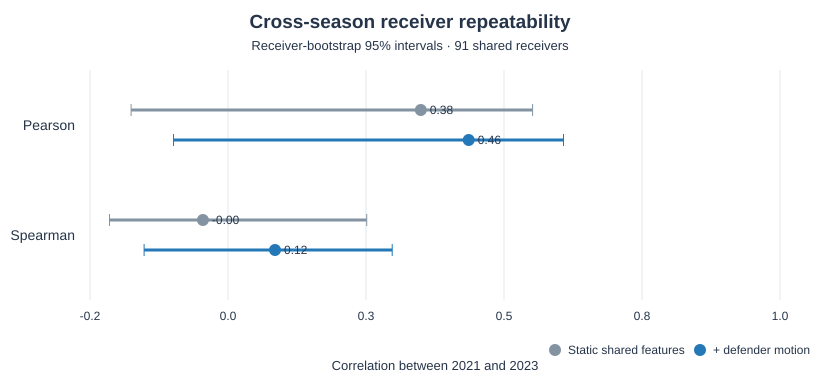

Comparison,Pearson gain,Pearson 95% lower,Pearson 95% upper,Spearman gain,Spearman 95% lower,Spearman 95% upper
dynamic_minus_static,0.083277,0.000972,0.135162,0.125386,-0.028957,0.144842


In [7]:
def reliability_svg(metrics, width=820, height=390):
    model_rows = [row for row in metrics if row["comparison"] in {"static", "dynamic"}]
    left, right, top, bottom = 90, 780, 70, 300
    axis_min = min(
        float(row[f"{stat}_ci_lower"])
        for row in model_rows
        for stat in ("pearson", "spearman")
    )
    axis_min = math.floor(axis_min * 5) / 5
    axis_max = 1.0
    scale = (right - left) / (axis_max - axis_min)
    x_coord = lambda value: left + (float(value) - axis_min) * scale
    parts = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">',
        '<rect width="100%" height="100%" fill="white"/>',
        '<style>text{font-family:Arial,sans-serif;fill:#253449}.grid{stroke:#e4e9ef}</style>',
        f'<text x="{width/2}" y="28" text-anchor="middle" font-size="19" font-weight="bold">Cross-season receiver repeatability</text>',
        f'<text x="{width/2}" y="50" text-anchor="middle" font-size="13">Receiver-bootstrap 95% intervals · {model_rows[0]["receivers"]} shared receivers</text>',
    ]
    for tick in range(6):
        value = axis_min + (axis_max - axis_min) * tick / 5
        x = x_coord(value)
        parts.extend([
            f'<line class="grid" x1="{x:.1f}" y1="{top}" x2="{x:.1f}" y2="{bottom}"/>',
            f'<text x="{x:.1f}" y="{bottom+20}" text-anchor="middle" font-size="12">{value:.1f}</text>',
        ])
    colors = {"static": "#8493a2", "dynamic": "#2478b7"}
    for index, stat in enumerate(("pearson", "spearman")):
        center = 125 + index * 110
        parts.append(f'<text x="{left-15}" y="{center+5}" text-anchor="end" font-size="14">{stat.title()}</text>')
        for j, row in enumerate(model_rows):
            y = center + (j - 0.5) * 30
            value = float(row[stat])
            low, high = float(row[f"{stat}_ci_lower"]), float(row[f"{stat}_ci_upper"])
            parts.extend([
                f'<line x1="{x_coord(low):.1f}" y1="{y}" x2="{x_coord(high):.1f}" y2="{y}" stroke="{colors[row["comparison"]]}" stroke-width="3"/>',
                f'<line x1="{x_coord(low):.1f}" y1="{y-6}" x2="{x_coord(low):.1f}" y2="{y+6}" stroke="{colors[row["comparison"]]}"/>',
                f'<line x1="{x_coord(high):.1f}" y1="{y-6}" x2="{x_coord(high):.1f}" y2="{y+6}" stroke="{colors[row["comparison"]]}"/>',
                f'<circle cx="{x_coord(value):.1f}" cy="{y}" r="6" fill="{colors[row["comparison"]]}"/>',
                f'<text x="{x_coord(value)+9:.1f}" y="{y+4}" font-size="12">{value:.2f}</text>',
            ])
    parts.extend([
        f'<text x="{(left+right)/2}" y="{height-20}" text-anchor="middle" font-size="13">Correlation between 2021 and 2023</text>',
        '<circle cx="555" cy="350" r="6" fill="#8493a2"/><text x="568" y="354" font-size="12">Static shared features</text>',
        '<circle cx="700" cy="350" r="6" fill="#2478b7"/><text x="713" y="354" font-size="12">+ defender motion</text>',
        '</svg>',
    ])
    return "".join(parts)


def html_table(rows, columns):
    heading = "".join(
        f'<th style="padding:6px 10px;text-align:left;border-bottom:2px solid #ccd5de">{html.escape(label)}</th>'
        for label, _ in columns
    )
    body = "".join(
        "<tr>" + "".join(
            f'<td style="padding:5px 10px;border-bottom:1px solid #e4e9ef">{html.escape(str(row[key]))}</td>'
            for _, key in columns
        ) + "</tr>"
        for row in rows
    )
    return HTML(f'<table style="border-collapse:collapse"> <thead><tr>{heading}</tr></thead><tbody>{body}</tbody></table>')


display(SVG(reliability_svg(reliability)))
html_table(
    [row for row in reliability if row["comparison"] == "dynamic_minus_static"],
    [
        ("Comparison", "comparison"),
        ("Pearson gain", "pearson"),
        ("Pearson 95% lower", "pearson_ci_lower"),
        ("Pearson 95% upper", "pearson_ci_upper"),
        ("Spearman gain", "spearman"),
        ("Spearman 95% lower", "spearman_ci_lower"),
        ("Spearman 95% upper", "spearman_ci_upper"),
    ],
)

In [8]:
eligible = [row for row in receiver_rows if row["eligible"] == "true"]
dynamic_order = sorted(eligible, key=lambda row: float(row["centered_residual_2021_dynamic"]) + float(row["centered_residual_2023_dynamic"]), reverse=True)
leaders = dynamic_order[:8] + dynamic_order[-8:]
leader_display_rows = [
    {
        "displayName": row["displayName"],
        "routes_2021_dynamic": row["routes_2021_dynamic"],
        "residual_2021": (
            f'{float(row["centered_residual_2021_dynamic"]):+.2f} '
            f'[{float(row["ci_lower_2021_dynamic"]):+.2f}, {float(row["ci_upper_2021_dynamic"]):+.2f}]'
        ),
        "routes_2023_dynamic": row["routes_2023_dynamic"],
        "residual_2023": (
            f'{float(row["centered_residual_2023_dynamic"]):+.2f} '
            f'[{float(row["ci_lower_2023_dynamic"]):+.2f}, {float(row["ci_upper_2023_dynamic"]):+.2f}]'
        ),
    }
    for row in leaders
]
html_table(
    leader_display_rows,
    [
        ("Receiver", "displayName"),
        ("Routes 2021", "routes_2021_dynamic"),
        ("2021 residual [95% CI]", "residual_2021"),
        ("Routes 2023", "routes_2023_dynamic"),
        ("2023 residual [95% CI]", "residual_2023"),
    ],
)

Receiver,Routes 2021,2021 residual [95% CI],Routes 2023,2023 residual [95% CI]
Isaiah McKenzie,21,"+2.34 [+1.32, +3.69]",35,"+1.25 [+0.39, +2.89]"
Rondale Moore,97,"+2.11 [+1.36, +3.01]",316,"+0.61 [+0.27, +0.93]"
Mecole Hardman,201,"+0.44 [+0.10, +0.71]",54,"+0.45 [-0.02, +1.13]"
Byron Pringle,120,"+0.63 [+0.25, +0.98]",73,"+0.26 [-0.16, +0.68]"
Laviska Shenault,179,"+0.36 [-0.07, +0.66]",24,"+0.45 [-0.63, +1.23]"
Elijah Moore,125,"+0.25 [-0.01, +0.65]",375,"+0.33 [+0.02, +0.69]"
DeAndre Carter,82,"-0.20 [-0.72, +0.83]",28,"+0.72 [-0.29, +2.02]"
Braxton Berrios,96,"+0.24 [-0.06, +0.63]",237,"+0.23 [-0.05, +0.56]"
Mike Evans,269,"-0.34 [-0.50, -0.19]",382,"-0.14 [-0.31, +0.01]"
Tee Higgins,158,"-0.38 [-0.58, -0.19]",275,"-0.15 [-0.30, +0.01]"


## Reading the result

Treat the cross-season correlation as a repeatability check. A positive correlation means receivers who are above (or below) their season's route-level expectation in 2021 tend, on average, to be on the same side of expectation in 2023. The comparison between static and dynamic models tells us whether adding pre-release defender movement makes these player-level estimates more repeatable. It does not show that the metric has isolated individual route-running skill: role, route assignment, health, teammates, and tracking-label differences remain in the residual.

With the 20-route/five-game requirement, 91 of 128 shared receiver IDs qualify. The dynamic model has a higher observed Pearson correlation than the static model (0.459 vs 0.375), while the observed Spearman correlations are 0.122 vs -0.004. The nested paired bootstrap estimates a Pearson gain of +0.083 (95% interval +0.001 to +0.135); the Spearman gain is +0.125, but its interval (-0.029 to +0.145) includes zero. Absolute-correlation intervals are broad and include zero. This is tentative evidence of improved agreement in receiver residual levels, while a ranking improvement remains uncertain. Season-centering removes the common residual bias before comparing players.

In [9]:
summary = {
    "shared players eligible": receiver_checks["eligible_shared_players"],
    "receiver reliability": reliability,
    "season route-level biases": {
        key: value for key, value in receiver_checks.items() if "route_bias" in key
    },
    "name IDs with season discrepancy": sum(row["name_consistent"] == "false" for row in receiver_rows),
}
summary

{'shared players eligible': 91, 'receiver reliability': [{'comparison': 'static', 'receivers': '91', 'pearson': '0.375327', 'pearson_ci_lower': '-0.128488', 'pearson_ci_upper': '0.569805', 'spearman': '-0.003679', 'spearman_ci_lower': '-0.166022', 'spearman_ci_upper': '0.281155'}, {'comparison': 'dynamic', 'receivers': '91', 'pearson': '0.458604', 'pearson_ci_lower': '-0.054859', 'pearson_ci_upper': '0.623548', 'spearman': '0.121707', 'spearman_ci_lower': '-0.105845', 'spearman_ci_upper': '0.325602'}, {'comparison': 'dynamic_minus_static', 'receivers': '91', 'pearson': '0.083277', 'pearson_ci_lower': '0.000972', 'pearson_ci_upper': '0.135162', 'spearman': '0.125386', 'spearman_ci_lower': '-0.028957', 'spearman_ci_upper': '0.144842'}], 'season route-level biases': {'2021_static_route_bias': -0.0014440980345857897, '2023_static_route_bias': -0.011584789112152006, '2021_dynamic_route_bias': -0.001164169716357247, '2023_dynamic_route_bias': -0.06118295645676575}, 'name IDs with season disc